# Autocomplete working inside Jupyter

GitHub Copilot autocomplete works directly inside Jupyter notebooks, so you can get suggestions while writing Python code in a cell. As you type, Copilot looks at the current cell and nearby context, then proposes likely continuations such as function calls, loops, plotting code, or data processing steps.

This is especially useful in notebooks because the workflow is iterative: you try something, inspect the output, and then refine the next cell. Instead of memorizing full APIs, you can use autocomplete to move faster, explore ideas, and stay focused on the analysis. It is still worth reviewing each suggestion carefully, because the LLM can produce code that looks correct but does not match your data or goal.

In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

def load_california_housing():
    data = fetch_california_housing()
    X = pd.DataFrame(data.data, columns=data.feature_names)
    y = pd.Series(data.target, name='MedHouseVal')
    return X, y

# Chat can analyze and modify code in Jupyter

GitHub Copilot Chat can also analyze and modify code in Jupyter notebooks. You can ask it to explain what a cell does, suggest improvements, or even write new cells based on your instructions. For example, you could say "Explain this code" or "Add a plot of the results" and it will generate the appropriate code for you.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load data
X, y = load_california_housing()
housing_df = X.copy()
housing_df["MedHouseVal"] = y

# Quick preview
display(housing_df.head())

# 1) Distribution of all features + target (Seaborn)
cols = housing_df.columns
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=housing_df, x=col, bins=30, kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribution: {col}")

for j in range(i + 1, len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# WebSearch as a source of information

GitHub Copilot Chat can use tools like WebSearch to find up-to-date information from the web. This is especially useful when working with rapidly evolving libraries or APIs, as it can provide the latest documentation, examples, and best practices. You can ask it questions like "How do I use the latest version of pandas to read a CSV file?" and it will search the web for relevant information and incorporate it into its response.

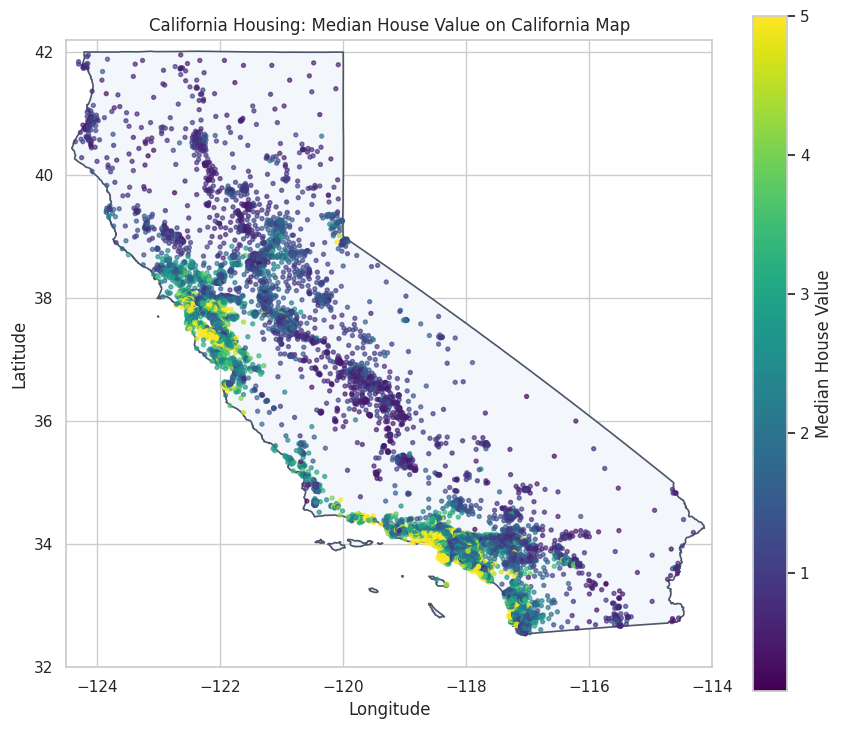

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 2) Geographic view using GeoPandas + Matplotlib (accurate California boundary)
states_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_500k.zip"
states = gpd.read_file(states_url).to_crs(epsg=4326)
california = states.loc[states["NAME"] == "California"]

# Convert housing points to a GeoDataFrame (lon/lat)
housing_gdf = gpd.GeoDataFrame(
    housing_df.copy(),
    geometry=gpd.points_from_xy(housing_df["Longitude"], housing_df["Latitude"]),
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(9, 10))

# Accurate California geometry
california.plot(ax=ax, facecolor="#f3f6fa", edgecolor="#4c566a", linewidth=1.2)

# Housing points colored by target value
housing_gdf.plot(
    ax=ax,
    column="MedHouseVal",
    cmap="viridis",
    markersize=8,
    alpha=0.65,
    legend=True,
    legend_kwds={"label": "Median House Value", "shrink": 0.7},
)

ax.set_xlim(-124.5, -114.0)
ax.set_ylim(32.0, 42.2)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("California Housing: Median House Value on California Map")
plt.tight_layout()
plt.show()